# About The Data

link https://www.kaggle.com/datasets/trainingdatapro/age-detection-human-faces-18-60-years/data


The dataset is a collection of images of people from various age groups. It has been specifically curated for age prediction and face recognition tasks. The dataset encompasses diverse demographics, ethnicities, and genders.

Age groups of people in the dataset: 18-20, 21-30, 31-40, 41-50 and 51-60

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os , math , shutil , glob
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

2025-10-26 15:03:34.407139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761491014.430185    1346 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761491014.437147    1346 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Load The Data

In [2]:
train_ds = keras.utils.image_dataset_from_directory(        # library we have to import
    directory = '/kaggle/input/age-detection-human-faces-18-60-years/train',  # path of train data
    labels='inferred',
   label_mode='categorical',
    batch_size=32,
    image_size=(256,256)
)

Found 125 files belonging to 5 classes.


I0000 00:00:1761491018.038260    1346 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/age-detection-human-faces-18-60-years/test',   # test data 
    labels='inferred',
    label_mode='categorical',
    batch_size=32,
    image_size=(256,256)
)

Found 25 files belonging to 5 classes.


In [4]:
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label


train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

## Model

In [5]:
from keras.layers import Flatten, Dense
from keras.models import Model
from keras.applications.mobilenet import MobileNet
from keras.callbacks import ModelCheckpoint, EarlyStopping
import tensorflow as tf
from tensorflow import keras
# Base model
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout, BatchNormalization)
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam

# Input + preprocessing
base_model = MobileNet(input_shape=(256, 256, 3), include_top=False, weights='imagenet')

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Define new model
X = Flatten()(base_model.output)
X = Dense(128, activation='relu')(X)  
X = Dense(5, activation='softmax')(X)  
model = Model(inputs=base_model.input, outputs=X)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/tmp/ipykernel_1346/2338447369.py:23: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 128, 128, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 129, 129, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 64, 64, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 64, 64, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 64, 64, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 64, 64, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 11,618,245 (44.32 MB)

 Trainable params: 8,389,381 (32.00 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

mc = ModelCheckpoint(
    filepath='bestmodel.keras',
    monitor='val_mae',     # <-- regression metric
    mode='min',            # lower is better
    save_best_only=True,
    verbose=1
)

es = EarlyStopping(
    monitor='val_mae',     # <-- regression metric
    mode='min',
    min_delta=1e-3,        # ~0.001 years improvement
    patience=5,
    restore_best_weights=True,
    verbose=1
)

rlr = ReduceLROnPlateau(
    monitor='val_mae',
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

cb = [es, mc, rlr]


In [7]:
history = model.fit(
    train_ds,
    steps_per_epoch=50,
    epochs=100,
    verbose=1,
    callbacks=cb,
    validation_data=validation_ds,
    validation_steps=16
)

Epoch 1/100


I0000 00:00:1761491025.430885    1399 service.cc:148] XLA service 0x7fe7a4004340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761491025.430960    1399 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
Invalid SOS parameters for sequential JPEG
I0000 00:00:1761491026.337924    1399 cuda_dnn.cc:529] Loaded cuDNN version 90300
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG


 1/50 ━━━━━━━━━━━━━━━━━━━━ 7:06 9s/step - accuracy: 0.1250 - loss: 3.1483

I0000 00:00:1761491029.148168    1399 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 4/50 ━━━━━━━━━━━━━━━━━━━━ 36s 800ms/step - accuracy: 0.1390 - loss: 25.4848

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 1.0000 - loss: 5.1436e-05 - val_accuracy: 0.1600 - val_loss: 5.0732 - learning_rate: 0.0010
Epoch 100/100
 2/50 ━━━━━━━━━━━━━━━━━━━━ 39s 825ms/step - accuracy: 1.0000 - loss: 4.6827e-05

Invalid SOS parameters for sequential JPEG


 3/50 ━━━━━━━━━━━━━━━━━━━━ 34s 731ms/step - accuracy: 1.0000 - loss: 5.2382e-05

Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 1.0000 - loss: 5.1782e-05 - val_accuracy: 0.1600 - val_loss: 5.0743 - learning_rate: 0.0010


In [8]:
model.save('final_model.h5')

## Results

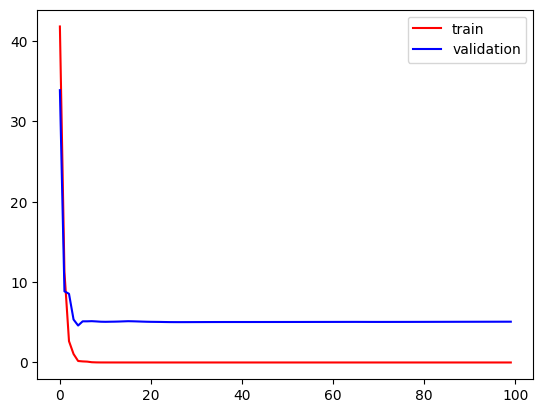

In [9]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

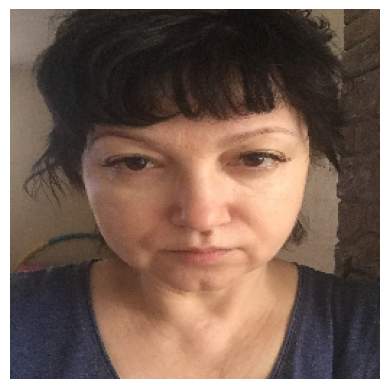

Shape of input array: (256, 256, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted class index: 4
Predicted class probability: 0.9997167
Predicted class name: 51-60


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing.image import img_to_array, load_img
from keras.applications.mobilenet import preprocess_input

# Define the image path
path = "/kaggle/input/age-detection-human-faces-18-60-years/train/51-60/10.jpg"

# Load and preprocess the image
img = load_img(path, target_size=(256, 256))
input_arr = img_to_array(img)
input_arr = preprocess_input(input_arr)  # Use the preprocessing function for MobileNet

# Visualize the image
plt.imshow((input_arr + 1) / 2)  # Display the image with correct scaling; MobileNet preprocess_input can result in values in [-1, 1]
plt.axis('off')  # Hide axis
plt.show()

# Check the shape of the array
print("Shape of input array:", input_arr.shape)

# Add a batch dimension
input_arr = np.expand_dims(input_arr, axis=0)

# Make prediction
predictions = model.predict(input_arr)

# Get the predicted class
predicted_class_index = np.argmax(predictions[0])  # Get the index of the highest probability
predicted_class_probability = np.max(predictions[0])  # Get the probability of the predicted class

print("Predicted class index:", predicted_class_index)
print("Predicted class probability:", predicted_class_probability)

# Map predicted class index to class name (assuming you have a list of class names)
class_names = ['18-20', '21-30', '31-40','41-50','51-60']  
predicted_class_name = class_names[predicted_class_index]

print("Predicted class name:", predicted_class_name)